In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")
import torch
from torch.distributions import Normal
from sbi.inference import NPE_A, NPE_B
from sbi.analysis import pairplot
import scipy
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from torch.distributions import Exponential, Normal, InverseGamma, MultivariateNormal
from sbi.utils import MultipleIndependent, BoxUniform

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


# Define the simulator

In [2]:
def one_step_update(af, bf, Vf, tau, ll, psi, vf_prev, xf_prev, vl_prev, xl_prev, bl):
    vff = max(0, vf_prev + 2.5 * af * tau * (1 - vf_prev / Vf) * np.sqrt(max(0, 0.025 + vf_prev / Vf)))
    vcf = max(0, bf * tau + np.sqrt(max(0, bf**2 * tau**2 - bf * (2 * (xl_prev - ll - xf_prev) - vf_prev * tau - (vl_prev**2)/(psi * bl)))))
    return min(vff, vcf)

def follower_trajectory(af, bf, Vf, tau, ll, psi, vf0, xf0, vl, xl, N, bl):
    xf = [xf0]
    vf = [vf0]
    xf_prev = xf0
    vf_prev = vf0
    for step in range(1, N+1):
        xl_prev = xl[step - 1]
        vl_prev = vl[step - 1]
        vf_new = one_step_update(af, bf, Vf, tau, ll, psi, vf_prev, xf_prev, vl_prev, xl_prev, bl)
        xf_new = xf_prev + tau * (vf_prev + vf_new)/2
        xf.append(xf_new)
        vf.append(vf_new)
        xf_prev = xf_new
        vf_prev = vf_new
    return xf, vf

def simulate_leader_trajectory(al, bl, Vl, tau, xl0, vl0, N, p_accel, p_brake):
    xl = [xl0]
    vl = [vl0]
    xl_prev = xl0
    vl_prev = vl0
    for step in range(1, N+1):

        u = np.random.rand()
        if u < p_accel:
            vl_new = max(0, vl_prev + al * tau)
        elif u < p_accel + p_brake:
            vl_new = max(0, vl_prev + bl * tau)
        else:
            vl_new = max(0, vl_prev + 2.5 * al * tau * (1 - vl_prev / Vl) * np.sqrt(max(0, 0.025 + vl_prev / Vl)))
        vl.append(vl_new)
        xl_new = xl_prev + tau * (vl_prev + vl_new)/2
        xl.append(xl_new)
        xl_prev = xl_new
        vl_prev = vl_new
    return xl, vl

In [3]:
tau = 0.5
N = 200  # Number of tau-sized time steps to simulate
T = tau * N  # Total time simulated

af = 2
bf = -2 * af
Vf = 25
psi = 1.3
xf0 = 0
vf0 = 10

al = 2
bl = -2 * al
Vl = 20
ll = 6.5 # Length of leader car
p_accel = 0.15
p_brake = 0.15
xl0 = 10
vl0 = 10


In [4]:
xl, vl = simulate_leader_trajectory(al, bl, Vl, tau, xl0, vl0, N, p_accel, p_brake)

In [5]:
xf, vf = follower_trajectory(af, bf, Vf, tau, ll, psi, vf0, xf0, vl, xl, N, bl)

In [6]:
def plot_xf_and_xl(xf, xl):
    fig, ax = plt.subplots(figsize=(10,5))
    t_range = tau * np.arange(0, N+1)
    ax.plot(t_range, xf, color="blue", label=r"Displacement of follower $x_f$")
    ax.plot(t_range, xl, color="red", label=r"Displacement of leader $x_l$")
    ax.set_xlabel(r"Time (s)")
    ax.set_ylabel("Displacement")
    if N < 250:
        ax.set_xticks(t_range, minor=True)
    plt.legend()
    plt.show()

def plot_diff_xf_and_xl(xf, xl):
    fig, ax = plt.subplots(figsize=(10,5))
    t_range = tau * np.arange(0, N+1)
    ax.plot(t_range, np.array(xl) - np.array(xf) - ll, color="black", label=r"Distance between follower and leader $x_l - x_f - \ell_l$")
    ax.set_xlabel(r"Time (s)")
    ax.set_ylabel("Distance between follower and leader")
    if N < 250:
        ax.set_xticks(t_range, minor=True)
    plt.legend()
    plt.show()

def plot_vf_and_vl(vf, vl):
    fig, ax = plt.subplots(figsize=(10,5))
    t_range = tau * np.arange(0, N+1)
    ax.plot(t_range, vf, color="blue", label=r"Velocity of follower $v_f$")
    ax.plot(t_range, vl, color="red", label=r"Velocity of leader $v_l$")
    ax.set_xlabel(r"Time (s)")
    ax.set_ylabel("Velocity")
    if N < 250:
        ax.set_xticks(t_range, minor=True)
    plt.legend()
    plt.show()

def plot_all(xf, vf, xl, vl):
    fig, ax = plt.subplots(figsize=(10,10), nrows=3, ncols=1)
    t_range = tau * np.arange(0, N+1)

    ax[0].plot(t_range, xf, color="blue", label=r"Displacement of follower $x_f$")
    ax[0].plot(t_range, xl, color="red", label=r"Displacement of leader $x_l$")
    ax[0].set_xlabel(r"Time (s)")
    ax[0].set_ylabel("Displacement (m)")
    ax[0].legend()

    ax[1].plot(t_range, np.array(xl) - np.array(xf) - ll, color="black", label=r"Distance between leader and follower $x_l - x_f - \ell_l$")
    ax[1].set_xlabel(r"Time (s)")
    ax[1].set_ylabel("Distance between leader and follower (m)")
    ax[1].legend()

    ax[2].plot(t_range, vf, color="blue", label=r"Velocity of follower $v_f$")
    ax[2].plot(t_range, vl, color="red", label=r"Velocity of leader $v_l$")
    ax[2].set_xlabel(r"Time (s)")
    ax[2].set_ylabel(r"Velocity $(ms^{-1})$")
    ax[2].legend()

    if N < 250:
        ax[0].set_xticks(t_range, minor=True)
        ax[1].set_xticks(t_range, minor=True)
        ax[2].set_xticks(t_range, minor=True)

    plt.tight_layout()
    plt.show()

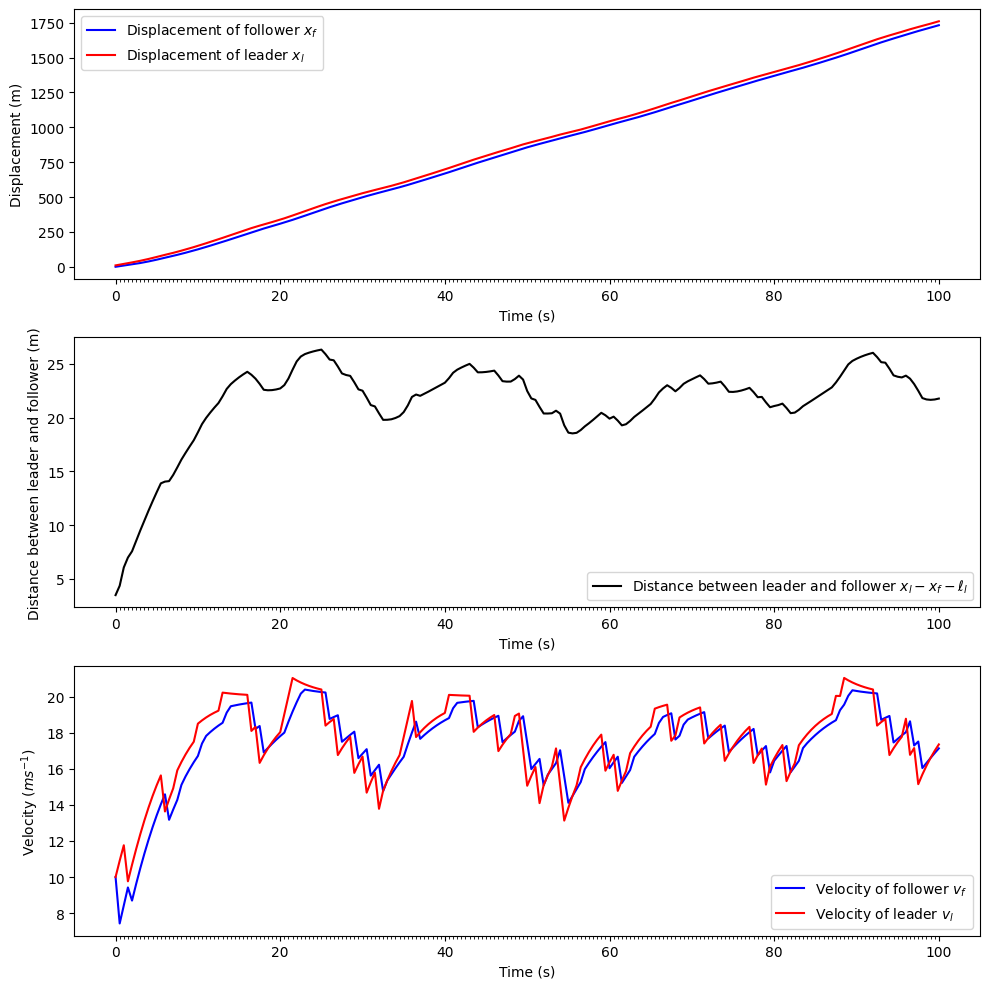

In [7]:
plot_all(xf, vf, xl, vl)

# SBI to infer Gipps parameters

In [8]:
# We assume the following variables are fixed globally:
tau = 0.5
N = 200  # Number of tau-sized time steps to simulate
T = tau * N  # Total time simulated
psi = 1.3
ll = 6.5 # Length of leader car

# For simulating leader trajectory
al = 2
bl = -2 * al
Vl = 20
p_accel = 0.15
p_brake = 0.15
xl0 = 10
vl0 = 10

# Here we fix the observation noise
mu = 0
sigmasquared = 1


In [9]:
# Leader trajectory is FIXED THROUGHOUT THE PROBLEM
xl, vl = simulate_leader_trajectory(al, bl, Vl, tau, xl0, vl0, N, p_accel, p_brake)

Denote the parameter vector as

$$\theta = (a_f, b_f, V_f, x_f(0), v_f(0))$$

In [10]:
def follow_trajectory_stochastic(af, bf, Vf, xf0, vf0):
    """
    af, bf, Vf, xv0, vf0 are the BAYESIAN PARAMETERS. 
    All other arguments are fixed.
    """
    xf, vf = follower_trajectory(af, bf, Vf, tau, ll, psi, vf0, xf0, vl, xl, N, bl)
    xf = torch.tensor(xf) 
    noise = torch.distributions.MultivariateNormal(mu*torch.ones(N+1), covariance_matrix=sigmasquared*torch.eye(N+1)).sample()
    return xf + noise, torch.tensor(vf) # Returns torch.tensors

def model(theta):
    """
    theta = torch.tensor([af, bf, Vf, xv0, vf0])
    """
    theta = theta.reshape(-1, 5)
    n_samples = theta.shape[0]
    simulations = torch.zeros((n_samples, N+1))
    for simulation in range(n_samples):
        af, bf, Vf, xf0, vf0 = theta[simulation, :]
        simulated_data, _ = follow_trajectory_stochastic(af, bf, Vf, xf0, vf0)
        simulations[simulation, :] = simulated_data
    return simulations
    

In [11]:
# Simulate synthetic observed data
af = 3
bf = -5
Vf = 25
xf0 = 0
vf0 = 10

true_theta = torch.tensor([af, bf, Vf, xf0, vf0])

x_obs, v_obs = follow_trajectory_stochastic(af, bf, Vf, xf0, vf0)

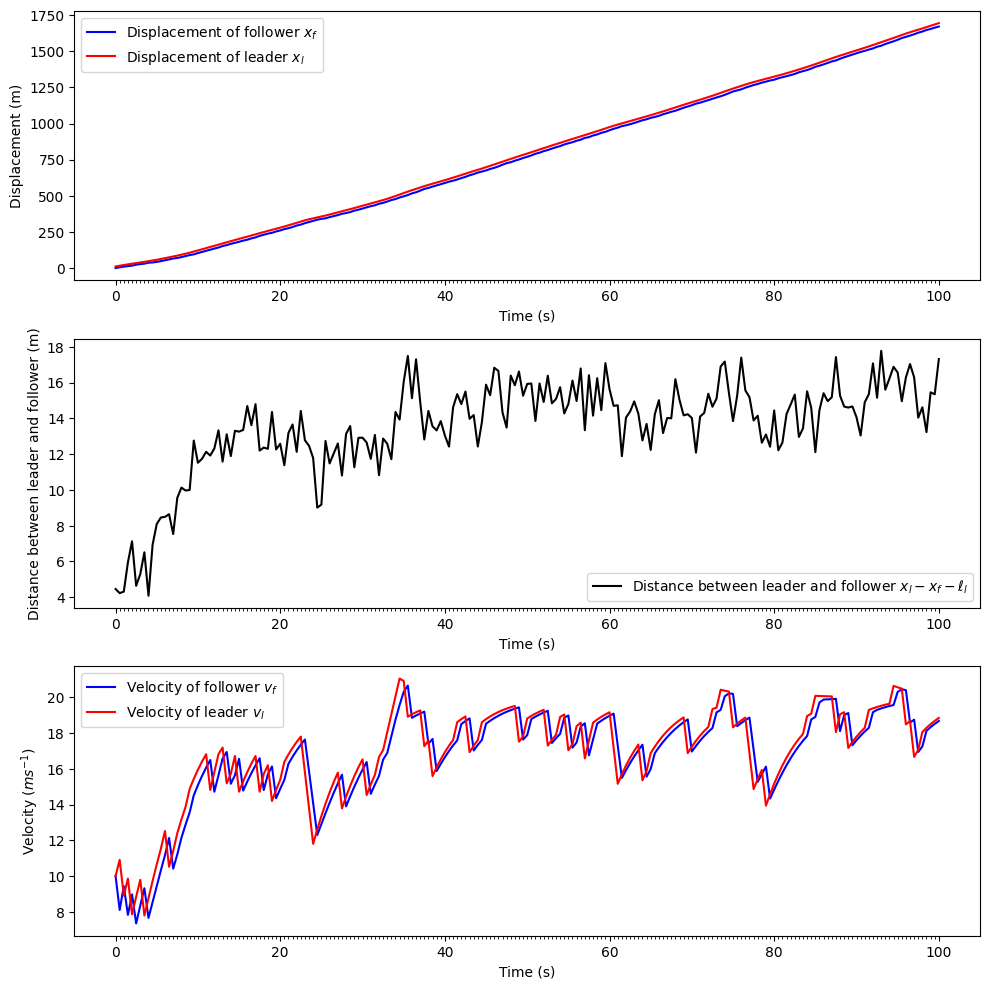

In [12]:
plot_all(x_obs, v_obs, xl, vl)

In [13]:
# SNPE-A NEEDS UNOFORM OR GAUSSIAN PRIOR
aL, aU = 0.5, 3.5
bL, bU = -6, -1
VL, VU = 15, 35
xf0L, xf0U = -40, 10
vf0L, vf0U = 5, 25

prior = BoxUniform(
                    torch.tensor([aL, bL, VL, xf0L, vf0L]),
                    torch.tensor([aU, bU, VU, xf0U, vf0U])
                   )

# For plotting
prior_supports = [(aL, aU), (bL, bU), (VL, VU), (xf0L, xf0U), (vf0L, vf0U)]

In [14]:
inference = NPE_A(prior=prior)  # (S)NPE-A algorithm (fast epsilon-free inference)
num_simulations = 2000  # number of (theta, x) pairs sampled and trained on
parameter_samples = prior.sample((num_simulations,))  # simulate parameters from prior
data_samples = model(parameter_samples)  # simulate data for each parameter
inference = inference.append_simulations(parameter_samples, data_samples)
density_estimator = inference.train()
posterior = inference.build_posterior()

 Neural network successfully converged after 88 epochs.

In [15]:
samples = posterior.sample((10000,), x=x_obs)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

Clear non-identifiability issue with $x_f(0)$ and $v_f(0)$ (look at the correlations). Since if we start further back but have a larger initial velocity, we can achieve a very similar trajectory.

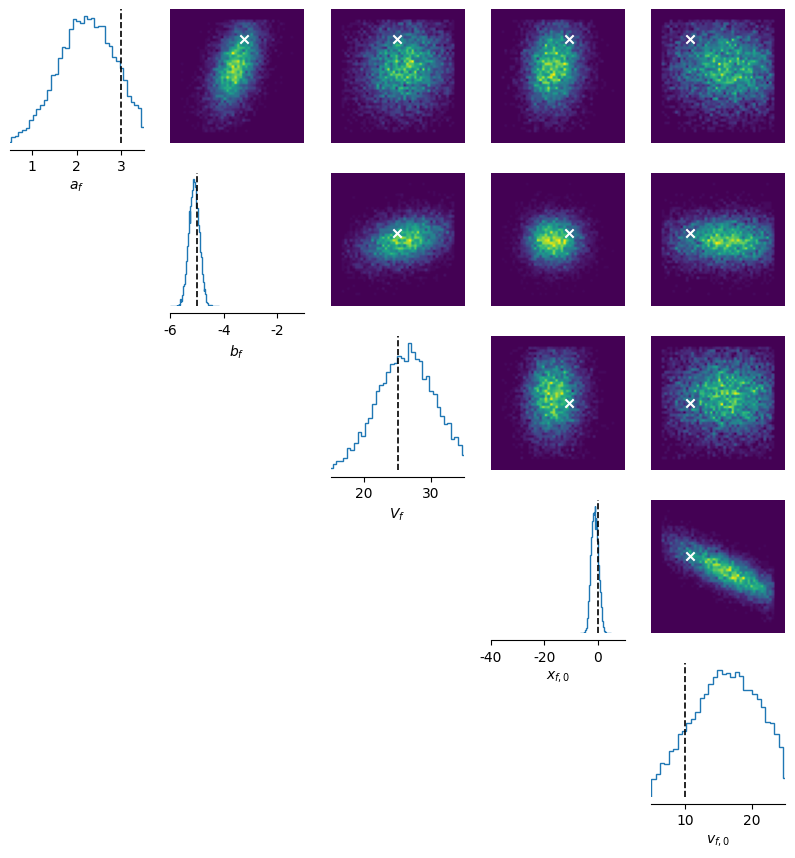

In [16]:
fig = pairplot(samples, 
         labels=[r"$a_f$", r"$b_f$", r"$V_f$", r"$x_{f,0}$", r"$v_{f,0}$"],
         figsize=(10,10));

axes = fig[0].axes   # flat list of all subplots
dim = 5


for i in range(dim):        # row index
    for j in range(dim):    # column index
        ax = axes[i * dim + j]

        if i == j:
            # 1D marginal → vertical line
            ax.axvline(true_theta[i], color="black", linestyle="--", linewidth=1.2)
            ax.set_xlim(prior_supports[i])

        elif j > i:
            # 2D joint → horizontal AND vertical lines
            ax.scatter(true_theta[j], true_theta[i], color="white", marker="x")


# SBC

In [17]:
from sbc_utils.sbc_tools import plot_sbc_ecdf_diff, sbc_ranks, plot_sbc_ecdf, plot_sbc_histogram, plot_sbc_all

In [18]:
# Projection test function
def test_function_projection(theta, i):
    """
    theta is a 1D or 2D torch.tensor 

    project theta onto its i'th dimension
    """
    if theta.dim() == 1:
        return theta[i]
    else:
        # In this case, theta is (batch_size, parameter_dimension)
        return theta[:, i]

In [19]:
N_iter = 1000
N_samp = 100
ranks_dimension_0 = sbc_ranks(model, prior, posterior, test_function=lambda x: test_function_projection(x, 0), N_iter=N_iter, N_samp=N_samp)


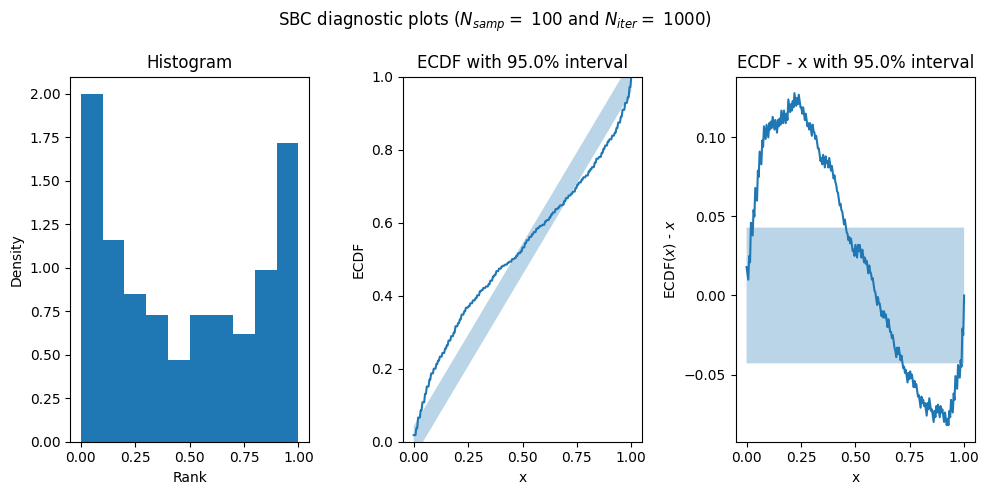

array([<Axes: title={'center': 'Histogram'}, xlabel='Rank', ylabel='Density'>,
       <Axes: title={'center': 'ECDF with 95.0% interval'}, xlabel='x', ylabel='ECDF'>,
       <Axes: title={'center': 'ECDF - x with 95.0% interval'}, xlabel='x', ylabel='ECDF($x$) - $x$'>],
      dtype=object)

In [20]:
plot_sbc_all(ranks_dimension_0, N_iter=N_iter, N_samp=N_samp)